In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New']
plt.rcParams['font.size']= 12
from scipy.interpolate import interp1d

scale=1.0e10
# Get the path of the script
script_path = os.path.dirname(os.path.realpath('.'))
if not script_path:
    script_path = '/home/amak/SolarAxionFlux/results'

# Plot settings
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}')

def plot_setup(size=6,ratio=0.618):
    fig.set_size_inches(size,ratio*size)
    ax.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=4)

In [7]:
# Load data for TP resonant m112-m124
tp_resonant_data = {}
masses_list = np.arange(112, 125)  # 112-124 eV
for n in masses_list:
    file_path = os.path.join(script_path, f'TP_resonant_m{n}.dat')
    if not os.path.exists(file_path):
        file_path = os.path.join(script_path, 'results', f'TP_resonant_m{n}.dat')
    tp_resonant_data[n] = np.genfromtxt(file_path)

/tmp/ipykernel_13962/52688038.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


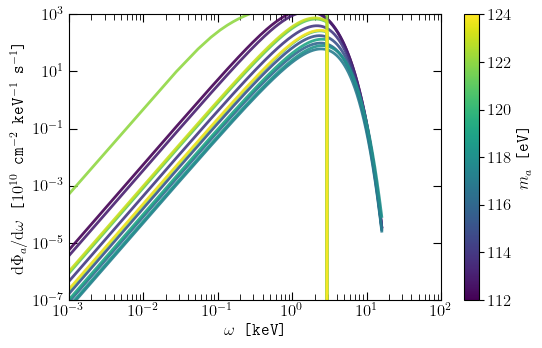

In [9]:
# Plot 1: Colormap plot of all masses
fig, ax = plt.subplots()
plot_setup()

# continuous colormap instead of discrete colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# colormap and normalization for 13 masses
cmap = cm.get_cmap('viridis')
norm = mcolors.Normalize(vmin=112, vmax=124)

# Plot all masses with color mapped to m_a
for i, mass in enumerate(masses_list):
    mass_data = tp_resonant_data[mass]
    flux = mass_data[:, 1] / scale
    ax.plot(mass_data[:, 0], flux, '-', color=cmap(norm(mass)), linewidth=2, alpha=0.9)

# Add colorbar instead of legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$m_a$ [eV]')

# Axis formatting
ax.set_xlabel(r'$\omega$ [keV]')
ax.set_ylabel(r'$\mathrm{d}\Phi_a/\mathrm{d}\omega$ ' r'[$10^{10}$ cm$^{-2}$ keV$^{-1}$ s$^{-1}$]')
ax.set_xlim(1e-3, 100)
ax.set_ylim(1e-7, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')

plt.savefig(script_path + "/all_massive_TP_colormap.pdf", bbox_inches='tight')
plt.show()
plt.close()

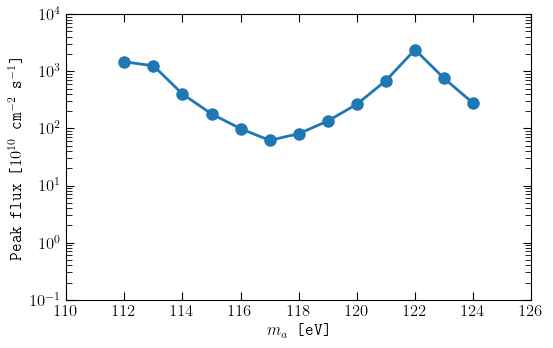

In [12]:
# Plot 2: Peak flux vs mass
masses = np.arange(112, 125)  # 112-124 eV
peak_flux = []

for n in masses:
    data = tp_resonant_data[n]
    flux = data[:, 1] / scale
    peak_flux.append(np.max(flux))

peak_flux = np.array(peak_flux)

fig, ax = plt.subplots()
plot_setup()

ax.plot(masses, peak_flux, 'o-', linewidth=2, markersize=8)
ax.set_xlim(110, 126)
ax.set_ylim(1e-1, 1e4)
ax.set_xlabel(r'$m_a$ [eV]')
ax.set_ylabel(r'Peak flux  [$10^{10}$ cm$^{-2}$ s$^{-1}$]')
ax.set_yscale('log')

plt.savefig(script_path + "/peak_flux_vs_mass.pdf", bbox_inches='tight')
plt.show()
plt.close()